In [2]:
# Importera bibliotek vi behöver
# pandas = tabeller/datahantering
# numpy = specialvärden som NaN
# pathlib = hittar rätt filväg oavsett var notebooken körs
# matplotlib och seaborn = grafer
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Hitta projektmappen
# Om notebooken ligger i /notebooks går vi ett steg upp till projektroten
project_folder = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Läs in dirty-filen
# Detta är vår "före cleaning"-version
dirty_path = project_folder / "data" / "dirty" / "yrbs_dirty_9vars.csv"
df_dirty = pd.read_csv(dirty_path)

print("Dirty-fil:", dirty_path)
print("Finns filen?", dirty_path.exists())

Dirty-fil: c:\Users\spiri\ws\yrbs-cleaning-project\data\dirty\yrbs_dirty_9vars.csv
Finns filen? True


In [6]:
# Välj bara Spirits kolumner
# row_id = id för att kunna spåra rader senare
# height_orig = längd
# social_media_use = sociala medier
# age = ålder
spirit_cols = ["row_id", "height_orig", "social_media_use", "age"]
df_spirit_dirty = df_dirty[spirit_cols].copy()

# Visa första raderna
df_spirit_dirty.head(20)

,row_id,height_orig,social_media_use,age
0,1,505,6.0,NaN
1,2,N N,4.0,NaN
2,3,506,8.0,NaN
3,4,N N,8.0,NaN
4,5,601,6.0,NaN
5,6,511,8.0,NaN
6,7,600,8.0,NaN
7,8,500,6.0,NaN
8,9,505,6.0,NaN
9,10,504,6.0,NaN


In [7]:
# Grundläggande överblick:
# shape = antal rader och kolumner
# info = datatyper och antal icke-tomma värden
print("Shape:")
print(df_spirit_dirty.shape)

print("\nInfo:")
df_spirit_dirty.info()

Shape:
(20118, 4)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 20118 entries, 0 to 20117
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   row_id            20118 non-null  int64
 1   height_orig       19849 non-null  str  
 2   social_media_use  15221 non-null  str  
 3   age               10 non-null     str  
dtypes: int64(1), str(3)
memory usage: 628.8 KB


In [8]:
# Hur många missing values finns i varje kolumn?
# Det här är en av de första EDA-kontrollerna
print("Missing values per kolumn:")
print(df_spirit_dirty.isna().sum())

Missing values per kolumn:
row_id                  0
height_orig           269
social_media_use     4897
age                 20108
dtype: int64


In [9]:
# Value counts visar vilka värden som faktiskt finns i varje kolumn
# Bra för att upptäcka konstiga kategorier, textfel och orimliga värden
print("Age values:")
print(df_spirit_dirty["age"].value_counts(dropna=False))

print("\nSocial media values:")
print(df_spirit_dirty["social_media_use"].value_counts(dropna=False))

print("\nHeight values:")
print(df_spirit_dirty["height_orig"].value_counts(dropna=False).head(30))

Age values:
age
NaN        20108
sixteen       10
Name: count, dtype: int64

Social media values:
social_media_use
6.0              5881
NaN              4897
8.0              4800
7.0              1183
1.0              1079
5.0               903
4.0               708
2.0               406
3.0               231
always online      10
1                  10
6                  10
Name: count, dtype: int64

Height values:
height_orig
504    1686
506    1685
507    1634
505    1590
503    1552
508    1541
510    1367
509    1335
502    1256
511    1113
600    1084
501     747
601     575
500     513
602     437
N N     341
411     321
NaN     269
603     255
604     127
605      83
711      67
410      64
409      41
606      26
5        26
607      24
609      24
408      21
300      20
Name: count, dtype: int64


In [10]:
# Slumpmässiga rader gör det lättare att se felen än head()
# Eftersom felen ligger utspridda i datasetet
df_spirit_dirty.sample(50, random_state=42)

,row_id,height_orig,social_media_use,age
451,452,506,6.0,NaN
17161,17162,503,NaN,NaN
4269,4270,509,6.0,NaN
16583,16584,505,NaN,NaN
16325,16326,510,NaN,NaN
17420,17421,510,NaN,NaN
17843,17844,508,8.0,NaN
15888,15889,510,NaN,NaN
3351,3352,503,8.0,NaN
19505,19506,608,8.0,NaN


In [12]:
# Skapa numeriska kopior för analys
# errors="coerce" betyder:
# - giltiga numeriska värden blir siffror
# - ogiltiga värden blir NaN
df_spirit_dirty["age_num"] = pd.to_numeric(df_spirit_dirty["age"], errors="coerce")
df_spirit_dirty["social_media_num"] = pd.to_numeric(df_spirit_dirty["social_media_use"], errors="coerce")
df_spirit_dirty["height_num"] = pd.to_numeric(df_spirit_dirty["height_orig"], errors="coerce")

df_spirit_dirty.head(20)

,row_id,height_orig,social_media_use,age,age_num,social_media_num,height_num
0,1,505,6.0,NaN,NaN,6.0,505.0
1,2,N N,4.0,NaN,NaN,4.0,NaN
2,3,506,8.0,NaN,NaN,8.0,506.0
3,4,N N,8.0,NaN,NaN,8.0,NaN
4,5,601,6.0,NaN,NaN,6.0,601.0
5,6,511,8.0,NaN,NaN,8.0,511.0
6,7,600,8.0,NaN,NaN,8.0,600.0
7,8,500,6.0,NaN,NaN,6.0,500.0
8,9,505,6.0,NaN,NaN,6.0,505.0
9,10,504,6.0,NaN,NaN,6.0,504.0


In [13]:
# describe ger översikt över numeriska variabler
# count, mean, std, min, max osv
print("Age describe:")
print(df_spirit_dirty["age_num"].describe())

print("\nSocial media describe:")
print(df_spirit_dirty["social_media_num"].describe())

print("\nHeight describe:")
print(df_spirit_dirty["height_num"].describe())

Age describe:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: age_num, dtype: float64

Social media describe:
count    15211.000000
mean         6.046151
std          1.984251
min          1.000000
25%          6.000000
50%          6.000000
75%          8.000000
max          8.000000
Name: social_media_num, dtype: float64

Height describe:
count    19508.000000
mean       516.516609
std         51.544700
min          3.000000
25%        504.000000
50%        507.000000
75%        510.000000
max        999.000000
Name: height_num, dtype: float64


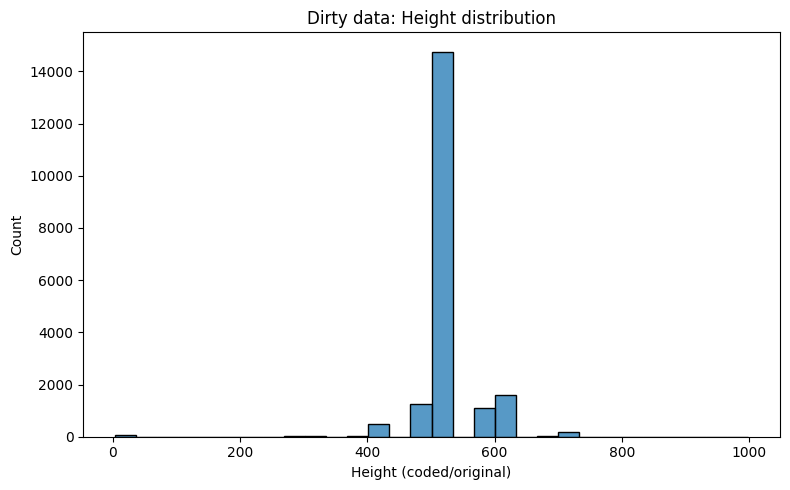

In [15]:
# Histogram för height_num
# Visar fördelning och hjälper oss se outliers och konstiga värden
plt.figure(figsize=(8, 5))
sns.histplot(df_spirit_dirty["height_num"], bins=30)
plt.title("Dirty data: Height distribution")
plt.xlabel("Height (coded/original)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

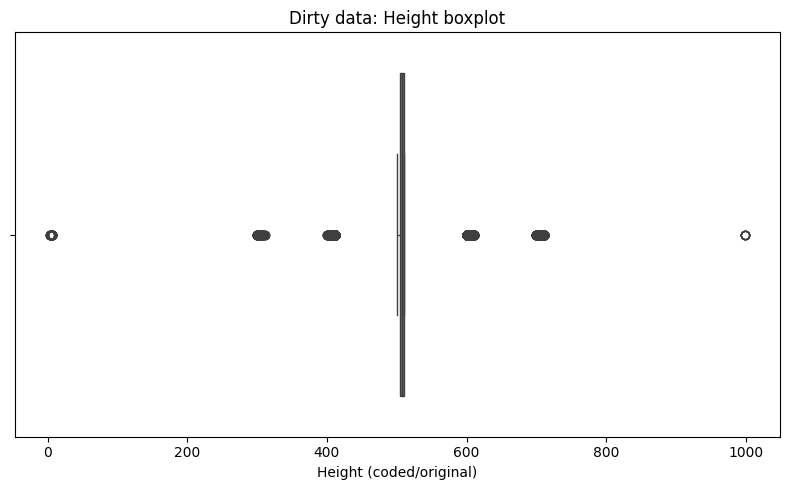

In [16]:
# Boxplot för height_num
# Bra för att se extrema värden tydligt
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_spirit_dirty["height_num"])
plt.title("Dirty data: Height boxplot")
plt.xlabel("Height (coded/original)")
plt.tight_layout()
plt.show()

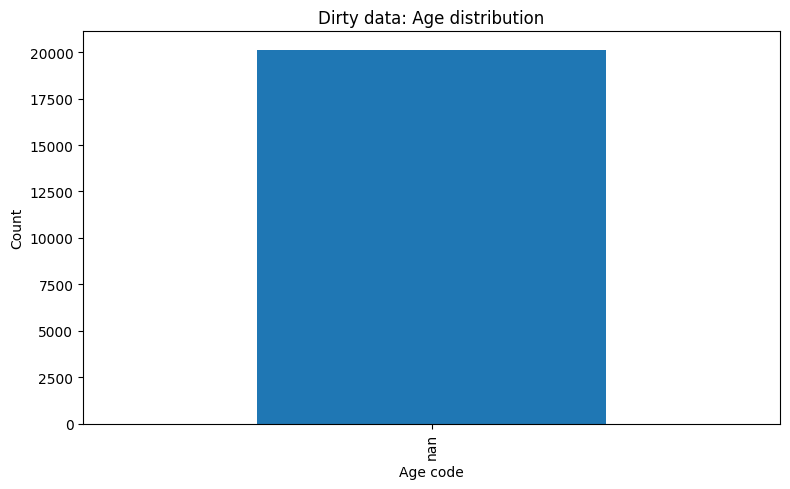

In [17]:
# Stapeldiagram för age_num
# Passar ordinal variabel
age_counts = df_spirit_dirty["age_num"].value_counts(dropna=False).sort_index()

plt.figure(figsize=(8, 5))
age_counts.plot(kind="bar")
plt.title("Dirty data: Age distribution")
plt.xlabel("Age code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

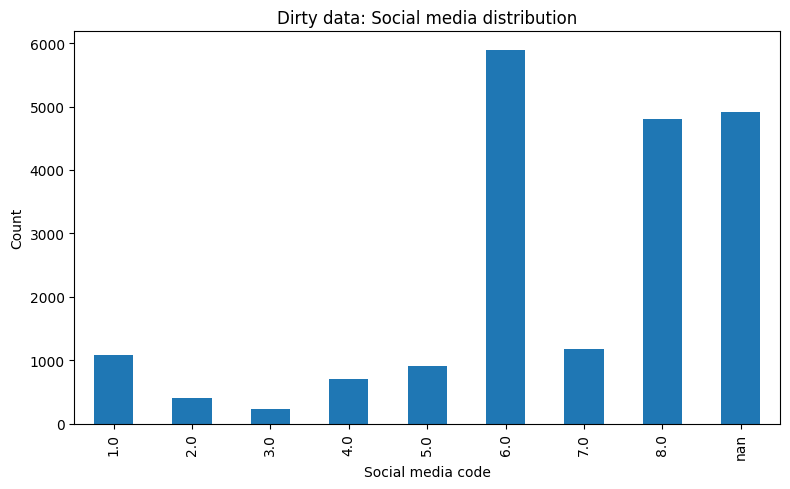

In [18]:
# Stapeldiagram för social_media_num
social_counts = df_spirit_dirty["social_media_num"].value_counts(dropna=False).sort_index()

plt.figure(figsize=(8, 5))
social_counts.plot(kind="bar")
plt.title("Dirty data: Social media distribution")
plt.xlabel("Social media code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()